In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
!git clone https://github.com/caoxiyang/damoxing.git

In [ ]:
!pip install --upgrade "chronos-forecasting>=2.0"
!pip install "transformers>=4.41,<5"

In [ ]:
!pip install autogluon
!pip install --upgrade pyarrow

In [ ]:
# 1. 安装 autogluon
!pip install autogluon

# 2. 强制卸载现有的 pyarrow 并安装特定版本
!pip uninstall -y pyarrow
!pip install --no-cache-dir pyarrow==17.0.0

In [ ]:
# 1. 强力卸载所有冲突包
# 1. 强力删除系统自带的、可能引起冲突的包
!pip uninstall -y pyarrow datasets autogluon chronos-forecasting

# 2. 安装 Chronos2 核心依赖的“稳定三角”：
# pyarrow 14.0.1 + datasets 2.15.0 + transformers 4.44.2
# 这组版本在 Python 3.12 上避开了大部分 PyExtensionType 的导出问题
!pip install --no-cache-dir pyarrow==14.0.1 datasets==2.15.0 
!pip install --no-cache-dir "transformers>=4.41,<5.0"
!pip install --no-cache-dir chronos-forecasting autogluon

# 3. 强制清理动态库缓存（黑科技）
import os
import signal

# 这一步会尝试杀掉当前的 Python 进程，强迫 Kaggle 重启一个新的、干净的内核
os.kill(os.getpid(), signal.SIGTERM)

In [ ]:
# -*- coding: utf-8 -*-
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error

from chronos import Chronos2Pipeline
model_dir = "/root/root/autodl-tmp/demo/chronos-2"
print("exists:", os.path.isdir(model_dir))
print("config:", os.path.isfile(os.path.join(model_dir, "config.json")))
print("weights:", os.path.isfile(os.path.join(model_dir, "model.safetensors")))
# --- 1. Read data ---
file_path = "/kaggle/input/datasets/zhanyi1/dataset/qqqqqqqq20240103_20251102_1315140401.csv"
print(f"Reading: {file_path}")
df = pd.read_csv(file_path)
df["plantid"] = df["plantid"].astype(str)
df["date"] = pd.to_datetime(df["date"])

# sort by id/time
df = df.sort_values(by=["plantid", "date"]).reset_index(drop=True)

# --- 2. Normalize target ---
target_col = "corrected_scada_power"
max_power = 252000
print(f"Max power: {max_power:.2f} (for normalization)")
df[target_col] = df[target_col] / max_power

# --- 3. Split by timesteps (per series length) ---
sample_id = df["plantid"].iloc[0]
single_ts_length = len(df[df["plantid"] == sample_id])

pred_steps = int(single_ts_length * 0.1)   # last 10% for test
val_steps = int(single_ts_length * 0.2)    # middle 20% for val
train_steps = single_ts_length - pred_steps - val_steps

print("--- Per series split ---")
print(f"series length: {single_ts_length}")
print(f"pred_steps (10%): {pred_steps}")
print(f"val_steps (20%): {val_steps}")
print(f"train_steps (70%): {train_steps}")

# split: 0-90% for context, 0-70% for train
def slice_by_steps(group, end_idx):
    # end_idx is exclusive
    return group.iloc[:end_idx]

train_df_list = []
context_df_list = []
test_df_list = []

for item_id, g in df.groupby("plantid"):
    g = g.sort_values("date")
    g_train = slice_by_steps(g, train_steps)
    g_context = slice_by_steps(g, train_steps + val_steps)
    g_test = g.iloc[-pred_steps:]

    train_df_list.append(g_train)
    context_df_list.append(g_context)
    test_df_list.append(g_test)

train_df = pd.concat(train_df_list).reset_index(drop=True)
context_df = pd.concat(context_df_list).reset_index(drop=True)
test_df = pd.concat(test_df_list).reset_index(drop=True)

# --- 4. Build fine-tuning inputs (no covariates) ---
train_inputs = []
for item_id, g in train_df.groupby("plantid"):
    train_inputs.append({
        "target": g[target_col].values
    })

# --- 5. Load model and fine-tune ---
# choose device_map="cuda" if you have GPU
# --- 5. Load model and fine-tune ---
import torch, gc

# 1. 强力清理显存残留
def clear_gpu():
    gc.collect()
    torch.cuda.empty_cache()
    if torch.cuda.is_available():
        torch.cuda.ipc_collect()

clear_gpu()

# 2. 加载模型：关键是 device_map="auto"
# 这会自动把模型权重分布在两张 GPU 上，单张卡就不会那么挤了
pipeline = Chronos2Pipeline.from_pretrained(
    r"/kaggle/working/damoxing/chronos-2",
    device_map="auto", 
    torch_dtype=torch.bfloat16, # 使用 bfloat16 节省一半显存 (T4 支持)
    local_files_only=True
)

# 3. 开始微调：大幅下调 batch_size
finetuned_pipeline = pipeline.fit(
    inputs=train_inputs,
    prediction_length=24,      # 微调时的预测长度建议设短（如24或48）
    context_length=512,        # 必须限制上下文长度，否则默认值可能很大导致 OOM
    finetune_mode="lora",      # 强烈建议用 lora，full 模式在 T4 上极难跑通
    batch_size=1,              # 降到最低 1，如果还崩就说明单条数据太长
    gradient_accumulation_steps=16, # 通过积累 16 步来达到等效 batch_size=16
    learning_rate=1e-4,
    num_steps=500,             # 步数可以先设少点测试
    logging_steps=50,
    # 启用以下设置防止碎片化
    tf32=False,                # T4 不支持 tf32，关闭以防万一
)
# --- 6. Predict ---
# 建议：将 prediction_length 限制在 1024 以内（例如 512 或 720）
actual_pred_steps = min(pred_steps, 512) 

print(f"正在进行推理，预测步数设定为: {actual_pred_steps}")

pred_df = finetuned_pipeline.predict_df(
    context_df,
    prediction_length=actual_pred_steps, # 缩短预测长度
    context_length=1024,                # 显式限制模型只看最近的 1024 个历史点
    quantile_levels=[0.1, 0.5, 0.9],
    id_column="plantid",
    timestamp_column="date",
    target=target_col,
    batch_size=8,                       # 减小预测时的 batch_size
)
# --- 7. Evaluate and plot (first id) ---
item_id = df["plantid"].iloc[0]

# pred_df is usually a flat frame with id_column; filter by id instead of .loc
pred_one = pred_df[pred_df["plantid"] == item_id].set_index("date").sort_index()
if pred_one.empty:
    raise KeyError(f"No predictions for plantid={item_id}")

pred_mean = pred_one["0.5"] * max_power
pred_01 = pred_one["0.1"] * max_power
pred_09 = pred_one["0.9"] * max_power

y_true_ts = test_df[test_df["plantid"] == item_id].set_index("date")[target_col] * max_power

common_index = y_true_ts.index.intersection(pred_mean.index)
y_true_aligned = y_true_ts.loc[common_index]
y_pred_aligned = pred_mean.loc[common_index]

if len(y_true_aligned) == 0:
    print("Error: no overlapping timestamps for evaluation.")
else:
    mae = mean_absolute_error(y_true_aligned, y_pred_aligned)
    rmse = np.sqrt(mean_squared_error(y_true_aligned, y_pred_aligned))
    accuracy = (1 - (mae / max_power)) * 100

    print(f"--- Eval (ID: {item_id}) ---")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"Accuracy: {accuracy:.2f}%")

    plt.figure(figsize=(12, 6))
    plt.plot(y_true_ts.index, y_true_ts.values, label="Ground Truth", color="black", linewidth=1.5)
    plt.plot(pred_mean.index, pred_mean.values, label="Prediction (median)", color="#FF3333", linewidth=1.5, linestyle="--")
    plt.fill_between(pred_mean.index, pred_01, pred_09, color="#FF3333", alpha=0.15, label="CI (0.1-0.9)")

    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H"))
    plt.gcf().autofmt_xdate()
    plt.title(f"Forecast for {item_id} (Acc: {accuracy:.2f}%)")
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.show()


In [ ]:
# -*- coding: utf-8 -*-
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error

from chronos import Chronos2Pipeline
model_dir = "/root/root/autodl-tmp/demo/chronos-2"
print("exists:", os.path.isdir(model_dir))
print("config:", os.path.isfile(os.path.join(model_dir, "config.json")))
print("weights:", os.path.isfile(os.path.join(model_dir, "model.safetensors")))
# --- 1. Read data ---
file_path = "/kaggle/input/datasets/zhanyi1/dataset/qqqqqqqq20240103_20251102_1315140401.csv"
print(f"Reading: {file_path}")
df = pd.read_csv(file_path)
df["plantid"] = df["plantid"].astype(str)
df["date"] = pd.to_datetime(df["date"])

# sort by id/time
df = df.sort_values(by=["plantid", "date"]).reset_index(drop=True)

# --- 2. Normalize target ---
target_col = "corrected_scada_power"
max_power = 252000
print(f"Max power: {max_power:.2f} (for normalization)")
df[target_col] = df[target_col] / max_power

# --- 3. Split by timesteps (per series length) ---
sample_id = df["plantid"].iloc[0]
single_ts_length = len(df[df["plantid"] == sample_id])

pred_steps = int(single_ts_length * 0.1)   # last 10% for test
val_steps = int(single_ts_length * 0.2)    # middle 20% for val
train_steps = single_ts_length - pred_steps - val_steps

print("--- Per series split ---")
print(f"series length: {single_ts_length}")
print(f"pred_steps (10%): {pred_steps}")
print(f"val_steps (20%): {val_steps}")
print(f"train_steps (70%): {train_steps}")

# split: 0-90% for context, 0-70% for train
def slice_by_steps(group, end_idx):
    # end_idx is exclusive
    return group.iloc[:end_idx]

train_df_list = []
context_df_list = []
test_df_list = []

for item_id, g in df.groupby("plantid"):
    g = g.sort_values("date")
    g_train = slice_by_steps(g, train_steps)
    g_context = slice_by_steps(g, train_steps + val_steps)
    g_test = g.iloc[-pred_steps:]

    train_df_list.append(g_train)
    context_df_list.append(g_context)
    test_df_list.append(g_test)

train_df = pd.concat(train_df_list).reset_index(drop=True)
context_df = pd.concat(context_df_list).reset_index(drop=True)
test_df = pd.concat(test_df_list).reset_index(drop=True)

# --- 4. Build fine-tuning inputs (no covariates) ---
train_inputs = []
for item_id, g in train_df.groupby("plantid"):
    train_inputs.append({
        "target": g[target_col].values
    })

# --- 5. Load model and fine-tune ---
# choose device_map="cuda" if you have GPU
# --- 5. Load model and fine-tune ---
import torch, gc

# 1. 强力清理显存残留
def clear_gpu():
    gc.collect()
    torch.cuda.empty_cache()
    if torch.cuda.is_available():
        torch.cuda.ipc_collect()

clear_gpu()

# 2. 加载模型：关键是 device_map="auto"
# 这会自动把模型权重分布在两张 GPU 上，单张卡就不会那么挤了
pipeline = Chronos2Pipeline.from_pretrained(
    r"/kaggle/working/damoxing/chronos-2",
    device_map="auto", 
    torch_dtype=torch.bfloat16, # 使用 bfloat16 节省一半显存 (T4 支持)
    local_files_only=True
)

# 3. 开始微调：大幅下调 batch_size
finetuned_pipeline = pipeline.fit(
    inputs=train_inputs,
    prediction_length=24,      # 微调时的预测长度建议设短（如24或48）
    context_length=512,        # 必须限制上下文长度，否则默认值可能很大导致 OOM
    finetune_mode="lora",      # 强烈建议用 lora，full 模式在 T4 上极难跑通
    batch_size=4,              # 降到最低 1，如果还崩就说明单条数据太长
    gradient_accumulation_steps=16, # 通过积累 16 步来达到等效 batch_size=16
    learning_rate=1e-4,
    num_steps=1000,             # 步数可以先设少点测试
    logging_steps=50,
    # 启用以下设置防止碎片化
    tf32=False,                # T4 不支持 tf32，关闭以防万一
)
# --- 6. Predict ---
# 建议：将 prediction_length 限制在 1024 以内（例如 512 或 720）
actual_pred_steps = min(pred_steps, 512) 

print(f"正在进行推理，预测步数设定为: {actual_pred_steps}")

pred_df = finetuned_pipeline.predict_df(
    context_df,
    prediction_length=actual_pred_steps, # 缩短预测长度
    context_length=1024,                # 显式限制模型只看最近的 1024 个历史点
    quantile_levels=[0.1, 0.5, 0.9],
    id_column="plantid",
    timestamp_column="date",
    target=target_col, 
    batch_size=16,                       # 减小预测时的 batch_size
)
# --- 7. Evaluate and plot (first id) ---
item_id = df["plantid"].iloc[0]

# pred_df is usually a flat frame with id_column; filter by id instead of .loc
pred_one = pred_df[pred_df["plantid"] == item_id].set_index("date").sort_index()
if pred_one.empty:
    raise KeyError(f"No predictions for plantid={item_id}")

pred_mean = pred_one["0.5"] * max_power
pred_01 = pred_one["0.1"] * max_power
pred_09 = pred_one["0.9"] * max_power

y_true_ts = test_df[test_df["plantid"] == item_id].set_index("date")[target_col] * max_power

common_index = y_true_ts.index.intersection(pred_mean.index)
y_true_aligned = y_true_ts.loc[common_index]
y_pred_aligned = pred_mean.loc[common_index]

if len(y_true_aligned) == 0:
    print("Error: no overlapping timestamps for evaluation.")
else:
    mae = mean_absolute_error(y_true_aligned, y_pred_aligned)
    rmse = np.sqrt(mean_squared_error(y_true_aligned, y_pred_aligned))
    accuracy = (1 - (mae / max_power)) * 100

    print(f"--- Eval (ID: {item_id}) ---")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"Accuracy: {accuracy:.2f}%")

    plt.figure(figsize=(12, 6))
    plt.plot(y_true_ts.index, y_true_ts.values, label="Ground Truth", color="black", linewidth=1.5)
    plt.plot(pred_mean.index, pred_mean.values, label="Prediction (median)", color="#FF3333", linewidth=1.5, linestyle="--")
    plt.fill_between(pred_mean.index, pred_01, pred_09, color="#FF3333", alpha=0.15, label="CI (0.1-0.9)")

    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H"))
    plt.gcf().autofmt_xdate()
    plt.title(f"Forecast for {item_id} (Acc: {accuracy:.2f}%)")
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.show()


In [ ]:
# -*- coding: utf-8 -*-
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error

from chronos import Chronos2Pipeline
model_dir = "/root/root/autodl-tmp/demo/chronos-2"
print("exists:", os.path.isdir(model_dir))
print("config:", os.path.isfile(os.path.join(model_dir, "config.json")))
print("weights:", os.path.isfile(os.path.join(model_dir, "model.safetensors")))
# --- 1. Read data ---
file_path = "/kaggle/input/datasets/zhanyi1/dataset/qqqqqqqq20240103_20251102_1315140401.csv"
print(f"Reading: {file_path}")
df = pd.read_csv(file_path)
df["plantid"] = df["plantid"].astype(str)
df["date"] = pd.to_datetime(df["date"])

# sort by id/time
df = df.sort_values(by=["plantid", "date"]).reset_index(drop=True)

# --- 2. Normalize target ---
target_col = "corrected_scada_power"
max_power = 252000
print(f"Max power: {max_power:.2f} (for normalization)")
df[target_col] = df[target_col] / max_power

# --- 3. Split by timesteps (per series length) ---
sample_id = df["plantid"].iloc[0]
single_ts_length = len(df[df["plantid"] == sample_id])

pred_steps = int(single_ts_length * 0.1)   # last 10% for test
val_steps = int(single_ts_length * 0.2)    # middle 20% for val
train_steps = single_ts_length - pred_steps - val_steps

print("--- Per series split ---")
print(f"series length: {single_ts_length}")
print(f"pred_steps (10%): {pred_steps}")
print(f"val_steps (20%): {val_steps}")
print(f"train_steps (70%): {train_steps}")

# split: 0-90% for context, 0-70% for train
def slice_by_steps(group, end_idx):
    # end_idx is exclusive
    return group.iloc[:end_idx]

train_df_list = []
context_df_list = []
test_df_list = []

for item_id, g in df.groupby("plantid"):
    g = g.sort_values("date")
    g_train = slice_by_steps(g, train_steps)
    g_context = slice_by_steps(g, train_steps + val_steps)
    g_test = g.iloc[-pred_steps:]

    train_df_list.append(g_train)
    context_df_list.append(g_context)
    test_df_list.append(g_test)

train_df = pd.concat(train_df_list).reset_index(drop=True)
context_df = pd.concat(context_df_list).reset_index(drop=True)
test_df = pd.concat(test_df_list).reset_index(drop=True)

# --- 4. Build fine-tuning inputs (no covariates) ---
train_inputs = []
for item_id, g in train_df.groupby("plantid"):
    train_inputs.append({
        "target": g[target_col].values
    })

# --- 5. Load model and fine-tune ---
# choose device_map="cuda" if you have GPU
# --- 5. Load model and fine-tune ---
import torch, gc

# 1. 强力清理显存残留
def clear_gpu():
    gc.collect()
    torch.cuda.empty_cache()
    if torch.cuda.is_available():
        torch.cuda.ipc_collect()

clear_gpu()

# 2. 加载模型：关键是 device_map="auto"
# 这会自动把模型权重分布在两张 GPU 上，单张卡就不会那么挤了
pipeline = Chronos2Pipeline.from_pretrained(
    r"/kaggle/working/damoxing/chronos-2",
    device_map="auto", 
    torch_dtype=torch.bfloat16, # 使用 bfloat16 节省一半显存 (T4 支持)
    local_files_only=True
)

# 3. 开始微调：大幅下调 batch_size
finetuned_pipeline = pipeline.fit(
    inputs=train_inputs,
    prediction_length=24,      # 微调时的预测长度建议设短（如24或48）
    context_length=512,        # 必须限制上下文长度，否则默认值可能很大导致 OOM
    finetune_mode="lora",      # 强烈建议用 lora，full 模式在 T4 上极难跑通
    batch_size=8,              # 降到最低 1，如果还崩就说明单条数据太长
    gradient_accumulation_steps=16, # 通过积累 16 步来达到等效 batch_size=16
    learning_rate=1e-4,
    num_steps=500,             # 步数可以先设少点测试
    logging_steps=50,
    # 启用以下设置防止碎片化
    tf32=False,                # T4 不支持 tf32，关闭以防万一
)
# --- 6. Predict ---
# 建议：将 prediction_length 限制在 1024 以内（例如 512 或 720）
actual_pred_steps = min(pred_steps, 512) 

print(f"正在进行推理，预测步数设定为: {actual_pred_steps}")

pred_df = finetuned_pipeline.predict_df(
    context_df,
    prediction_length=actual_pred_steps, # 缩短预测长度
    context_length=1024,                # 显式限制模型只看最近的 1024 个历史点
    quantile_levels=[0.1, 0.5, 0.9],
    id_column="plantid",
    timestamp_column="date",
    target=target_col,
    batch_size=16, 
   
)
# --- 7. Evaluate and plot (first id) ---
item_id = df["plantid"].iloc[0]

# pred_df is usually a flat frame with id_column; filter by id instead of .loc
pred_one = pred_df[pred_df["plantid"] == item_id].set_index("date").sort_index()
if pred_one.empty:
    raise KeyError(f"No predictions for plantid={item_id}")

pred_mean = pred_one["0.5"] * max_power
pred_01 = pred_one["0.1"] * max_power
pred_09 = pred_one["0.9"] * max_power

y_true_ts = test_df[test_df["plantid"] == item_id].set_index("date")[target_col] * max_power

common_index = y_true_ts.index.intersection(pred_mean.index)
y_true_aligned = y_true_ts.loc[common_index]
y_pred_aligned = pred_mean.loc[common_index]

if len(y_true_aligned) == 0:
    print("Error: no overlapping timestamps for evaluation.")
else:
    mae = mean_absolute_error(y_true_aligned, y_pred_aligned)
    rmse = np.sqrt(mean_squared_error(y_true_aligned, y_pred_aligned))
    accuracy = (1 - (mae / max_power)) * 100

    print(f"--- Eval (ID: {item_id}) ---")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"Accuracy: {accuracy:.2f}%")

    plt.figure(figsize=(12, 6))
    plt.plot(y_true_ts.index, y_true_ts.values, label="Ground Truth", color="black", linewidth=1.5)
    plt.plot(pred_mean.index, pred_mean.values, label="Prediction (median)", color="#FF3333", linewidth=1.5, linestyle="--")
    plt.fill_between(pred_mean.index, pred_01, pred_09, color="#FF3333", alpha=0.15, label="CI (0.1-0.9)")

    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H"))
    plt.gcf().autofmt_xdate()
    plt.title(f"Forecast for {item_id} (Acc: {accuracy:.2f}%)")
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.show()


In [ ]:
# -*- coding: utf-8 -*-
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler  # <--- 新增：引入标准化工具
import torch
import gc
from chronos import Chronos2Pipeline

# ==========================================
# 0. 清理显存 (防止之前的报错残留)
# ==========================================
gc.collect()
torch.cuda.empty_cache()

model_dir = "/kaggle/working/damoxing/chronos-2"
print("exists:", os.path.isdir(model_dir))

# ==========================================
# --- 1. 读取数据 ---
# ==========================================
file_path = "/kaggle/input/datasets/zhanyi1/dataset/qqqqqqqq20240103_20251102_1315140401.csv"
print(f"Reading: {file_path}")
df = pd.read_csv(file_path)
df["plantid"] = df["plantid"].astype(str)
df["date"] = pd.to_datetime(df["date"])

# 排序
df = df.sort_values(by=["plantid", "date"]).reset_index(drop=True)

# ==========================================
# --- 2. 目标值 Z-score 标准化 (核心优化) ---
# ==========================================
target_col = "corrected_scada_power"
scaler = StandardScaler()  # 实例化标准化器

# 拟合并且转换数据
print("正在使用 StandardScaler 进行数据标准化...")
df[target_col] = scaler.fit_transform(df[[target_col]])

# ==========================================
# --- 3. 划分数据集 ---
# ==========================================
sample_id = df["plantid"].iloc[0]
single_ts_length = len(df[df["plantid"] == sample_id])

pred_steps = int(single_ts_length * 0.1)   # 测试集长度
val_steps = int(single_ts_length * 0.2)    # 验证集长度
train_steps = single_ts_length - pred_steps - val_steps

print("--- Per series split ---")
print(f"series length: {single_ts_length}")
print(f"train_steps (70%): {train_steps}")

def slice_by_steps(group, end_idx):
    return group.iloc[:end_idx]

train_df_list, context_df_list, test_df_list = [], [], []

for item_id, g in df.groupby("plantid"):
    g = g.sort_values("date")
    g_train = slice_by_steps(g, train_steps)
    g_context = slice_by_steps(g, train_steps + val_steps)
    g_test = g.iloc[-pred_steps:]

    train_df_list.append(g_train)
    context_df_list.append(g_context)
    test_df_list.append(g_test)

train_df = pd.concat(train_df_list).reset_index(drop=True)
context_df = pd.concat(context_df_list).reset_index(drop=True)
test_df = pd.concat(test_df_list).reset_index(drop=True)

# --- 4. 构建训练输入 ---
train_inputs = []
for item_id, g in train_df.groupby("plantid"):
    train_inputs.append({
        "target": g[target_col].values
    })

# ==========================================
# --- 5. 加载模型并微调 ---
# ==========================================
pipeline = Chronos2Pipeline.from_pretrained(
    model_dir,
    device_map="auto",  # 自动分配到两张 GPU
    local_files_only=True
)

print("开始模型微调...")
finetuned_pipeline = pipeline.fit(
    inputs=train_inputs,
    prediction_length=48,       # 微调时的内部预测长度
    context_length=512,         # 限制历史窗口，防止 OOM
    finetune_mode="lora",       # LoRA 微调
    learning_rate=1e-4,
    num_steps=500,              # 跑 500 步
    batch_size=4,               # 控制单卡显存
    gradient_accumulation_steps=8,
    logging_steps=50,
)

# ==========================================
# --- 6. 预测 (移除 0.95 分位数) ---
# ==========================================
actual_pred_steps = min(pred_steps, 512) 
print(f"\n正在进行推理，预测步数设定为: {actual_pred_steps} ...")

pred_df = finetuned_pipeline.predict_df(
    context_df,
    prediction_length=actual_pred_steps,
    quantile_levels=[0.1, 0.5, 0.9], # <--- 移除了 0.95
    id_column="plantid",
    timestamp_column="date",
    target=target_col,
    batch_size=4,  
)

# ==========================================
# --- 7. 反标准化、评估与画图 ---
# ==========================================
item_id = df["plantid"].iloc[0]
pred_one = pred_df[pred_df["plantid"] == item_id].set_index("date").sort_index()

# 反标准化
pred_mean_vals = scaler.inverse_transform(pred_one[["0.5"]]).flatten()
pred_01_vals = scaler.inverse_transform(pred_one[["0.1"]]).flatten()
pred_09_vals = scaler.inverse_transform(pred_one[["0.9"]]).flatten()

pred_mean = pd.Series(pred_mean_vals, index=pred_one.index)
pred_01 = pd.Series(pred_01_vals, index=pred_one.index)
pred_09 = pd.Series(pred_09_vals, index=pred_one.index)

# 真实值反标准化
test_one = test_df[test_df["plantid"] == item_id].set_index("date").iloc[:actual_pred_steps]
y_true_ts_vals = scaler.inverse_transform(test_one[[target_col]]).flatten()
y_true_ts = pd.Series(y_true_ts_vals, index=test_one.index)

# 对齐并计算误差
common_index = y_true_ts.index.intersection(pred_mean.index)
y_true_aligned = y_true_ts.loc[common_index]
y_pred_aligned = pred_mean.loc[common_index]

mae = mean_absolute_error(y_true_aligned, y_pred_aligned)
rmse = np.sqrt(mean_squared_error(y_true_aligned, y_pred_aligned))

# 计算准确率 (沿用你最初的公式)
max_power = 252000.00 
accuracy = (1 - (mae / max_power)) * 100

print(f"--- Eval (ID: {item_id}) ---")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"Accuracy: {accuracy:.2f}%") # <--- 打印准确率

# 画图
plt.figure(figsize=(14, 7))
plt.plot(y_true_ts.index, y_true_ts.values, label="Ground Truth", color="black", linewidth=1.5)
plt.plot(pred_mean.index, pred_mean.values, label="Prediction (Median)", color="#FF3333", linewidth=1.5, linestyle="-")
plt.fill_between(pred_mean.index, pred_01, pred_09, color="#FF3333", alpha=0.15, label="Confidence Interval (10%-90%)")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.gcf().autofmt_xdate()
plt.title(f"Forecast for {item_id} (Acc: {accuracy:.2f}%)") # <--- 标题显示准确率
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=== 第一阶段：特征工程 (Feature Engineering - 风电版) ===
=== 第二阶段：获取 Chronos 在验证集上的预测，并计算残差 ===
Chronos 正在回测验证集 (长度: 512)...
=== 第三阶段：训练 LightGBM 专门拟合阵风残差 ===
LightGBM 正在学习如何修正 Chronos 的平滑误差...
=== 第四阶段：未来预测大融合 (Test Set) ===
=== 第五阶段：评估与绘图对比 ===
单独 Chronos Accuracy: 73.18%
混合模型 (Chronos+LGBM) Accuracy: 56.75%


/tmp/ipykernel_283/4045262080.py:117: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_283/4045262080.py:117: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_283/4045262080.py:117: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missi

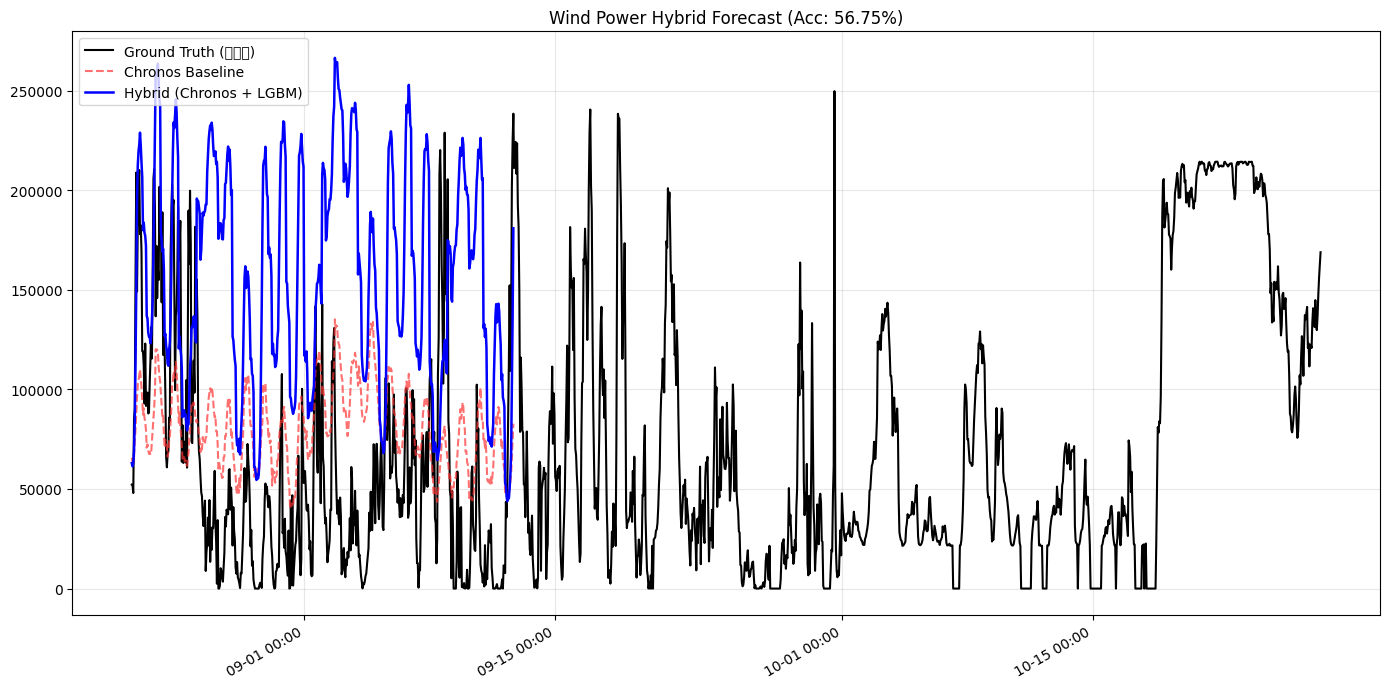

In [17]:
import lightgbm as lgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("=== 第一阶段：特征工程 (Feature Engineering - 风电版) ===")
# 确保此时的 df_lgb 是你经过 Chronos 预处理后的那个 df 的拷贝
df_lgb = df.copy() 
df_lgb['hour'] = df_lgb['date'].dt.hour
df_lgb['month'] = df_lgb['date'].dt.month
df_lgb['dayofweek'] = df_lgb['date'].dt.dayofweek
# 风电没有绝对的昼夜之分，但有很强的季节性，加入 dayofyear
df_lgb['dayofyear'] = df_lgb['date'].dt.dayofyear

# 我们只取你当前测试的那个电站 (item_id) 进行演示
df_item = df_lgb[df_lgb['plantid'] == item_id].sort_values("date").reset_index(drop=True)

print("=== 第二阶段：获取 Chronos 在验证集上的预测，并计算残差 ===")
# 提取用于 Chronos 预测的上下文 (前 70%) 和需要预测的验证集 (中间 20%)
train_chunk = df_item.iloc[:train_steps]
val_chunk = df_item.iloc[train_steps : train_steps + val_steps]

# 限制一下验证集的预测长度防止 OOM (比如只取前 512 步来训练 LightGBM)
val_pred_len = min(val_steps, 512)
val_chunk = val_chunk.iloc[:val_pred_len]

# 让 Chronos 预测这部分验证集
print(f"Chronos 正在回测验证集 (长度: {val_pred_len})...")
val_pred_df = finetuned_pipeline.predict_df(
    train_chunk, 
    prediction_length=val_pred_len, 
    quantile_levels=[0.5], 
    id_column="plantid", timestamp_column="date", target=target_col, batch_size=4
)

# 使用 max_power 进行反标准化，还原成实际功率
val_pred_median = val_pred_df["0.5"].values * max_power
val_true_power = val_chunk[target_col].values * max_power

# 计算残差 (真实功率 - Chronos预测的功率)
# 风电波动剧烈，Chronos 往往会预测得比较平滑，导致在阵风突变时残差很大
val_residuals = val_true_power - val_pred_median 

print("=== 第三阶段：训练 LightGBM 专门拟合阵风残差 ===")
# 去掉 is_daytime，换上风电适用的时间特征
features = ['hour', 'month', 'dayofweek', 'dayofyear']

X_train_lgb = val_chunk[features]
y_train_lgb = val_residuals

# 构建 LightGBM 数据集
lgb_train = lgb.Dataset(X_train_lgb, label=y_train_lgb)

# 设置 LGBM 参数 (风电残差噪音大，树不要太深，增加一点正则化防止过拟合)
params = {
     'objective': 'regression',
    'metric': 'mae',
    'learning_rate': 0.03,
    'max_depth': 6,
    'num_leaves': 45,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42
}

print("LightGBM 正在学习如何修正 Chronos 的平滑误差...")
gbm = lgb.train(params, lgb_train, num_boost_round=200)

print("=== 第四阶段：未来预测大融合 (Test Set) ===")
# 1. 之前你已经用 Chronos 预测了测试集，结果存在 pred_mean 里面
# pred_mean 就是我们要的 Baseline

# 2. 提取测试集的特征，让 LightGBM 预测误差
# 注意：确保 test_chunk 提取的长度和特征与实际对应
test_chunk = df_lgb[df_lgb['plantid'] == item_id].iloc[-pred_steps: -pred_steps + actual_pred_steps]
X_test_lgb = test_chunk[features]

# LightGBM 预测出来的“需要补偿的功率差值”
predicted_residuals = gbm.predict(X_test_lgb)

# 3. 【终极融合】: 最终预测 = Chronos基线 + LGBM预测的误差补偿
# 确保长度一致，提取公共索引
common_index = y_true_ts.index.intersection(pred_mean.index)
final_hybrid_predictions = pred_mean.loc[common_index].values + predicted_residuals[:len(common_index)]

# 防止出现负数发电量 (风电也不可能发负电)
final_hybrid_predictions = np.clip(final_hybrid_predictions, a_min=0, a_max=None)

print("=== 第五阶段：评估与绘图对比 ===")
# 计算融合后的误差
y_true_aligned = y_true_ts.loc[common_index].values
hybrid_mae = mean_absolute_error(y_true_aligned, final_hybrid_predictions)
hybrid_accuracy = (1 - (hybrid_mae / max_power)) * 100

print(f"单独 Chronos Accuracy: {accuracy:.2f}%")
print(f"混合模型 (Chronos+LGBM) Accuracy: {hybrid_accuracy:.2f}%")

# 画图：对比单纯 Chronos 和 混合模型
plt.figure(figsize=(14, 7))
plt.plot(y_true_ts.index, y_true_ts.values, label="Ground Truth (真实值)", color="black", linewidth=1.5)

# 画出单纯的 Chronos 预测
plt.plot(pred_mean.index, pred_mean.values, label="Chronos Baseline", color="#FF3333", linestyle="--", alpha=0.7)

# 画出 LGBM 修复后的预测 
plt.plot(common_index, final_hybrid_predictions, label="Hybrid (Chronos + LGBM)", color="blue", linewidth=1.8)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.gcf().autofmt_xdate()
plt.title(f"Wind Power Hybrid Forecast (Acc: {hybrid_accuracy:.2f}%)")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import lightgbm as lgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("=== 第一阶段：针对长序列的特征工程 (防穿越设计) ===")
# 假设 df 是你的原始数据，按时间和电站排序过
df_lgb = df.copy()

# 定义目标列和预测步长 (Horizon)
target_col = 'corrected_scada_power'
max_power = 252000 # 用于反标准化
HORIZON =24      # 假设我们要一次性预测未来 24 步 (比如 24 小时)

def create_long_term_features(group):
    d = group.copy()
    
    # 1. 时间特征 (未来的时间点你是知道的，所以不需要 shift)
    d['hour'] = d['date'].dt.hour
    d['month'] = d['date'].dt.month
    d['dayofyear'] = d['date'].dt.dayofyear
    
    # 2. 滞后特征 (极其关键：起点必须是 HORIZON)
    # 如果你要预测明天中午12点 (t)，你能拿到的最新数据是今天中午12点 (t-24)
    d['lag_H'] = d[target_col].shift(HORIZON)         # 24步前的值
    d['lag_H_plus_1'] = d[target_col].shift(HORIZON + 1) # 25步前的值
    d['lag_H_plus_2'] = d[target_col].shift(HORIZON + 2) # 26步前的值
    d['lag_H_plus_24'] = d[target_col].shift(HORIZON + 24) # 48步前的值 (前天同一时刻)
    
    # 一阶差分 (看24小时前的风力变化趋势)
    d['diff_H'] = d['lag_H'] - d['lag_H_plus_1']
    
    # 3. 滑动统计特征 (同样基于能够获取到的最新数据 lag_H 进行滑动)
    # 看 24 小时之前的那段窗口里的风力波动情况
    window_6 = d[target_col].shift(HORIZON).rolling(window=6)
    d['rolling_mean_6'] = window_6.mean()
    d['rolling_max_6'] = window_6.max()
    d['rolling_std_6'] = window_6.std() # 捕捉阵风和波动率
    
    window_12 = d[target_col].shift(HORIZON).rolling(window=12)
    d['rolling_mean_12'] = window_12.mean()
    
    return d

print(f"正在构建特征，预测盲区设定为 {HORIZON} 步...")
# 按电站分组构造特征，防止数据互相污染
df_features = df_lgb.groupby('plantid', group_keys=False).apply(create_long_term_features)

# 清除因为 shift 和 rolling 产生的 NaN 行
df_features = df_features.dropna().reset_index(drop=True)

# 选定我们刚造好的所有特征
features = [col for col in df_features.columns if col not in ['date', 'plantid', target_col]]

# 我们只取当前测试的那个电站进行演示
item_id = df_features['plantid'].iloc[0] 
df_item = df_features[df_features['plantid'] == item_id].sort_values("date").reset_index(drop=True)


print("=== 第二阶段：划分训练集与测试集 ===")
# 我们把最后 HORIZON 步（即最后 24 步）留作真正要预测的未来测试集
train_steps = len(df_item) - HORIZON

train_df = df_item.iloc[:train_steps]
test_df = df_item.iloc[train_steps:]

X_train = train_df[features]
y_train = train_df[target_col]

X_test = test_df[features]
y_test_true = test_df[target_col].values * max_power # 还原真实值


print("=== 第三阶段：训练 LightGBM ===")
lgb_train = lgb.Dataset(X_train, label=y_train)

# 风电的随机性大，参数稍微保守一点，防止过拟合历史噪音
params = {
    'objective': 'regression',
    'metric': 'mae',
    'learning_rate': 0.03,
    'max_depth': 6,
    'num_leaves': 45,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42
}

print("LightGBM 正在学习风的规律...")
gbm = lgb.train(params, lgb_train, num_boost_round=400)


print("=== 第四阶段：未来长序列预测 ===")
# 一次性预测未来 24 步！
raw_predictions = gbm.predict(X_test)

# 反标准化还原功率，并限制最低为 0
final_predictions = raw_predictions * max_power
final_predictions = np.clip(final_predictions, a_min=0, a_max=None)

# 评估误差
mae = mean_absolute_error(y_test_true, final_predictions)
accuracy = (1 - (mae / max_power)) * 100

print(f"--- 提前 {HORIZON} 步预测评估 (ID: {item_id}) ---")
print(f"MAE: {mae:.4f}")
print(f"Accuracy: {accuracy:.2f}%")


print("=== 第五阶段：结果可视化 ===")
plt.figure(figsize=(14, 7))

# 画图：最后一部分训练集的尾巴 + 测试集的真实值与预测值对比
# 为了让图好看点，我们带上预测点前 72 步的历史数据一起画
plot_history_steps = 72
history_df = train_df.iloc[-plot_history_steps:]

# 拼接历史和未来的时间轴与真实值
plot_dates = pd.concat([history_df['date'], test_df['date']])
plot_true_power = np.concatenate([history_df[target_col].values * max_power, y_test_true])

# 画真实曲线 (黑线)
plt.plot(plot_dates, plot_true_power, label="Ground Truth", color="black", linewidth=1.5)

# 画预测曲线 (橙色虚线)
plt.plot(test_df['date'], final_predictions, label=f"LGBM {HORIZON}-Step Forecast", color="#FF9900", linewidth=2.5, linestyle="--")

# 画一条垂直虚线，代表“此刻”（预测开始点）
plt.axvline(x=history_df['date'].iloc[-1], color='red', linestyle=':', label='Forecast Start (Now)')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.gcf().autofmt_xdate()
plt.title(f"Wind Power Long-Term Forecast (Acc: {accuracy:.2f}%)")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import lightgbm as lgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("=== 第一阶段：定义单步特征工程 (只看前一步) ===")
# 这里所有的特征都只用 shift(1)，因为我们的模型只负责预测“下一个点”
def create_step1_features(df_input, target_col):
    d = df_input.copy()
    
    # 时间特征
    d['hour'] = d['date'].dt.hour
    d['month'] = d['date'].dt.month
    
    # 滞后特征 (最近的几小时，以及昨天同一时间)
    d['lag_1'] = d[target_col].shift(1)
    d['lag_2'] = d[target_col].shift(2)
    d['lag_3'] = d[target_col].shift(3)
    d['lag_24'] = d[target_col].shift(24) 
    
    # 差分特征 (风力变化趋势)
    d['diff_1'] = d['lag_1'] - d['lag_2']
    
    # 滑动特征 (最近几小时的波动情况)
    d['rolling_mean_3'] = d[target_col].shift(1).rolling(3).mean()
    d['rolling_mean_6'] = d[target_col].shift(1).rolling(6).mean()
    d['rolling_std_6'] = d[target_col].shift(1).rolling(6).std()
    
    return d

# 假设 df 是你的原始数据，按时间和电站排序过
df_lgb = df.copy()
target_col = 'corrected_scada_power'
max_power = 252000 
HORIZON = 2400 # 预测未来 24 步

# 提取当前测试的电站
item_id = df_lgb['plantid'].iloc[0] 
df_item = df_lgb[df_lgb['plantid'] == item_id].sort_values("date").reset_index(drop=True)

# 生成训练用特征并清除 NaN
df_features = create_step1_features(df_item, target_col).dropna().reset_index(drop=True)

# 选定特征列
features = ['hour', 'month', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'diff_1', 'rolling_mean_3', 'rolling_mean_6', 'rolling_std_6']


print("=== 第二阶段：划分训练集 ===")
# 把最后 24 步切出来当测试集，剩下的全当训练集
train_steps = len(df_features) - HORIZON
train_df = df_features.iloc[:train_steps]

X_train = train_df[features]
y_train = train_df[target_col]

print("=== 第三阶段：训练 LightGBM (单步预测模型) ===")
lgb_train = lgb.Dataset(X_train, label=y_train)

# 树模型参数可以稍微精细一点，因为它只预测1步，任务比较简单
params = {
    'objective': 'regression',
    'metric': 'mae',
    'learning_rate': 0.05,
    'max_depth': 6,
    'num_leaves': 31,
    'verbose': -1,
    'random_state': 42
}

print("模型正在学习如何预测下一个点的风力...")
gbm = lgb.train(params, lgb_train, num_boost_round=300)


print("=== 第四阶段：滚动预测 (Autoregressive Loop) ===")
# 这是最核心的部分！我们要模拟现实中“走一步看一步”的过程

# 1. 准备一个“沙盘” DataFrame。
# 包含最后 100 步的历史真实数据（为了计算滞后特征），加上未来 24 步的时间戳
history_len = 100
df_sim = df_item.iloc[-(HORIZON + history_len):].copy().reset_index(drop=True)

# 2. 把未来 24 步的 target 变成 NaN（模拟未来数据未知）
# 我们只知道 df_sim 里面前 history_len 个点的真实功率
sim_start_idx = history_len
df_sim.loc[sim_start_idx:, target_col] = np.nan 

# 3. 提取出这 24 步的真实值，留作最后评估用
y_test_true = df_item[target_col].iloc[-HORIZON:].values * max_power

predicted_values = []

print("开始滚雪球式预测...")
# 循环预测未来的 24 步
for i in range(sim_start_idx, len(df_sim)):
    # a) 针对当前的沙盘，重新计算所有的特征
    # （因为上一步我们填入了一个新的预测值，所以滞后特征必须更新）
    df_sim_features = create_step1_features(df_sim, target_col)
    
    # b) 取出当前这一步 (第 i 行) 的特征
    current_X = df_sim_features.loc[[i], features]
    
    # c) 让 LightGBM 预测这 1 步
    pred_val = gbm.predict(current_X)[0]
    
    # d) 防止负数
    pred_val = max(0, pred_val)
    
    # e) 【关键操作】把预测出的功率填回沙盘里，当作下一步预测的“历史数据”！
    df_sim.loc[i, target_col] = pred_val
    
    # 保存记录
    predicted_values.append(pred_val)

# 反标准化还原预测出的功率
final_predictions = np.array(predicted_values) * max_power

# 评估误差
mae = mean_absolute_error(y_test_true, final_predictions)
accuracy = (1 - (mae / max_power)) * 100

print(f"--- 滚动预测 {HORIZON} 步评估 (ID: {item_id}) ---")
print(f"MAE: {mae:.4f}")
print(f"Accuracy: {accuracy:.2f}%")


print("=== 第五阶段：结果可视化 ===")
plt.figure(figsize=(14, 7))

# 画图：提取最近的真实历史数据
plot_history_steps = 72
history_dates = df_item['date'].iloc[-(HORIZON + plot_history_steps) : -HORIZON]
history_power = df_item[target_col].iloc[-(HORIZON + plot_history_steps) : -HORIZON] * max_power

test_dates = df_item['date'].iloc[-HORIZON:]

# 拼接并画出完整的真实曲线 (黑线)
plot_dates = pd.concat([history_dates, test_dates])
plot_true_power = np.concatenate([history_power.values, y_test_true])
plt.plot(plot_dates, plot_true_power, label="Ground Truth", color="black", linewidth=1.5)

# 画预测曲线 (蓝线)
plt.plot(test_dates, final_predictions, label=f"LGBM Rolling Forecast ({HORIZON} steps)", color="#0066CC", linewidth=2.5, linestyle="-")

# 分界线
plt.axvline(x=history_dates.iloc[-1], color='red', linestyle=':', label='Forecast Start (Now)')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.gcf().autofmt_xdate()
plt.title(f"Autoregressive Rolling Forecast (Acc: {accuracy:.2f}%)")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# -*- coding: utf-8 -*-
import os
import gc
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error
from chronos import Chronos2Pipeline

# ==========================================
# 准备工作：显存清理与参数设置
# ==========================================
def clear_gpu():
    gc.collect()
    torch.cuda.empty_cache()
    if torch.cuda.is_available():
        torch.cuda.ipc_collect()

clear_gpu()

# 定义全局参数
target_col = "corrected_scada_power"
max_power = 252000
CONTEXT_LEN = 192      # 模型回看过去 8 天 (192小时)
PRED_LEN = 24          # 微调时模型预测未来 1 天 (24小时)
STRIDE = 6             # 滑动切片的步长 (每6小时切一个样本)
TEST_STEPS = 512       # 最后留 512 步作为未见过的测试集

print("=== 第一阶段：读取数据与基础清洗 ===")
# 假设你已经读取了 df，这里为了代码完整性保留读取逻辑
# file_path = "/kaggle/input/datasets/zhanyi1/dataset/qqqqqqqq20240103_20251102_1315140401.csv"
# df = pd.read_csv(file_path)
# df["plantid"] = df["plantid"].astype(str)
# df["date"] = pd.to_datetime(df["date"])
# df = df.sort_values(by=["plantid", "date"]).reset_index(drop=True)

# 1. 数据归一化 (除以 max_power) 并裁剪异常值
print(f"最大功率基准: {max_power:.2f}，正在归一化并裁剪尖峰...")
df[target_col] = df[target_col] / max_power
df[target_col] = np.clip(df[target_col], a_min=0.0, a_max=1.0) # 防止传感器爆表产生的异常值


print("=== 第二阶段：滑动窗口数据增强 (榨干历史数据) ===")
train_inputs = [] 
test_df_list = []
context_for_test_list = [] # 用于最后测试时提供紧挨着的上下文

WINDOW_SIZE = CONTEXT_LEN + PRED_LEN 

for item_id, g in df.groupby("plantid"):
    g = g.sort_values("date").reset_index(drop=True)
    power_series = g[target_col].values
    
    # 划分出历史训练部分和最终测试部分
    train_df = g.iloc[:-TEST_STEPS]
    test_df_list.append(g.iloc[-TEST_STEPS:])
    
    # 把紧挨着测试集前面的 CONTEXT_LEN 长度的数据存起来，作为测试时的上下文
    context_for_test_list.append(g.iloc[-(TEST_STEPS + CONTEXT_LEN) : -TEST_STEPS])
    
    train_series = train_df[target_col].values
    
    # --- 核心：滑动切片增强 ---
    num_samples = 0
    for i in range(0, len(train_series) - WINDOW_SIZE + 1, STRIDE):
        window_chunk = train_series[i : i + WINDOW_SIZE]
        train_inputs.append({
            "target": window_chunk
        })
        num_samples += 1
        
    print(f"电站 {item_id} 扩增出了 {num_samples} 个微调样本！")

test_df = pd.concat(test_df_list).reset_index(drop=True)
context_test_df = pd.concat(context_for_test_list).reset_index(drop=True)
print(f"总计生成了 {len(train_inputs)} 个微调样本用于训练！")


print("=== 第三阶段：加载 Chronos 2.0 并进行微调 ===")
model_dir = r"/kaggle/working/damoxing/chronos-2"

pipeline = Chronos2Pipeline.from_pretrained(
    model_dir,
    device_map="auto", 
    torch_dtype=torch.bfloat16, 
    local_files_only=True
)

print("开始微调 (这将花费一些时间)...")
finetuned_pipeline = pipeline.fit(
    inputs=train_inputs,
    prediction_length=PRED_LEN,    # 与切片长度对应
    context_length=CONTEXT_LEN,    # 限制上下文，专注近期趋势
    finetune_mode="lora",      
    batch_size=4,                  # 样本变短了，batch_size 可以适当开到 2 或 4
    gradient_accumulation_steps=8, 
    learning_rate=2e-4,            # 样本量大，学习率适当调整
    num_steps=1500,                # 增加步数，让模型充分消化成百上千的样本
    logging_steps=100,
    tf32=False,                
)


print("=== 第四阶段：在测试集上进行预测 ===")
print(f"正在推理，预测未来 {TEST_STEPS} 步...")

# 使用刚才切出来的、紧挨着测试集的前 192 步作为上下文输入
pred_df = finetuned_pipeline.predict_df(
    context_test_df,
    prediction_length=TEST_STEPS,       
    context_length=CONTEXT_LEN,         # 显式限制模型只看最近的 CONTEXT_LEN 个点
    quantile_levels=[0.1, 0.5, 0.9],
    id_column="plantid",
    timestamp_column="date",
    target=target_col,
    batch_size=4,                       
)


print("=== 第五阶段：反标准化、评估与可视化 ===")
item_id = df["plantid"].iloc[0]

pred_one = pred_df[pred_df["plantid"] == item_id].set_index("date").sort_index()

# 反标准化：乘以 max_power 还原真实功率
pred_mean = pred_one["0.5"] * max_power
pred_01 = pred_one["0.1"] * max_power
pred_09 = pred_one["0.9"] * max_power

y_true_ts = test_df[test_df["plantid"] == item_id].set_index("date")[target_col] * max_power

# 提取公共索引对齐计算误差
common_index = y_true_ts.index.intersection(pred_mean.index)
y_true_aligned = y_true_ts.loc[common_index]
y_pred_aligned = pred_mean.loc[common_index]

if len(y_true_aligned) == 0:
    print("错误: 评估时没有找到重合的时间戳。")
else:
    mae = mean_absolute_error(y_true_aligned, y_pred_aligned)
    rmse = np.sqrt(mean_squared_error(y_true_aligned, y_pred_aligned))
    accuracy = (1 - (mae / max_power)) * 100

    print(f"--- 最终评估结果 (ID: {item_id}) ---")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"Accuracy: {accuracy:.2f}%")

    plt.figure(figsize=(14, 7))
    # 画出前一部分历史上下文（为了看清楚拼接处的趋势）
    history_plot = context_test_df[context_test_df["plantid"] == item_id].set_index("date")[target_col] * max_power
    plt.plot(history_plot.index[-100:], history_plot.values[-100:], label="Context History", color="gray", linewidth=1.5)
    
    # 画真实值与预测值
    plt.plot(y_true_ts.index, y_true_ts.values, label="Ground Truth (真实值)", color="black", linewidth=1.5)
    plt.plot(pred_mean.index, pred_mean.values, label="Chronos Augmented Prediction", color="#FF3333", linewidth=1.8, linestyle="-")
    plt.fill_between(pred_mean.index, pred_01, pred_09, color="#FF3333", alpha=0.15, label="Confidence Interval (0.1-0.9)")

    # 画一条红线代表预测起点
    plt.axvline(x=history_plot.index[-1], color='red', linestyle=':', label='Forecast Start')

    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H"))
    plt.gcf().autofmt_xdate()
    plt.title(f"Chronos 2.0 Wind Power Forecast (Augmented Acc: {accuracy:.2f}%)")
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()